In [1]:
from functools import partial
from pathlib import Path 
import sys# Ensure the workspace root is on sys.path so local packages (like `utils`) are importable
cwd = Path.cwd()
project_root = None
for parent in [cwd] + list(cwd.parents):
    if (parent / 'utils').is_dir() or (parent / '.git').exists():
        project_root = str(parent)
        break
if project_root is None:
    project_root = str(cwd)
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from utils.plotting import (
    compute_shap_values_loso,
    create_shap_summary_plot,
    handle_complex_numbers,
    load_feature_data_from_best_params,
    load_subject_data,
    utm_index_to_name,
)

best_parameters = {
    'spectral': ('CAR', 1, 'skew'),
    'cwt': ('BipolarDB', 60, 'std'),
    'dwt': ('Cz', 10, 'skew'),
    'mst': ('BipolarDB', 10, 'skew'),
    'sst': ('Laplacian', 20, 'skew'),
    'cc': ('Cz', 10, 'skew'),
    'plv': ('Laplacian', 2, 'std'),
    'gcc': ('CAR', 1, 'std'),
    'gplv': ('BipolarDB', 1, 'mean'),
    'utm': ('Laplacian', 60, 'mean'),
}

In [2]:
DATA_FOLDER = '/space/gzanardini/tuh_whole/split'

description, labels, subjects, unique_subjects, subject_labels = load_subject_data(DATA_FOLDER)
load_feature_data = partial(load_feature_data_from_best_params, DATA_FOLDER, best_parameters)

In [3]:
chs = ['FP1', 'F3', 'C3', 'P3', 'F7', 'T3', 'T5', 'O1', 'FZ', 'CZ',
       'PZ', 'FP2', 'F4', 'C4', 'P4', 'F8', 'T4', 'T6', 'O2']

feature_names = [utm_index_to_name(i, channels=chs) for i in range(247)]

100%|██████████| 31/31 [00:07<00:00,  4.02it/s]


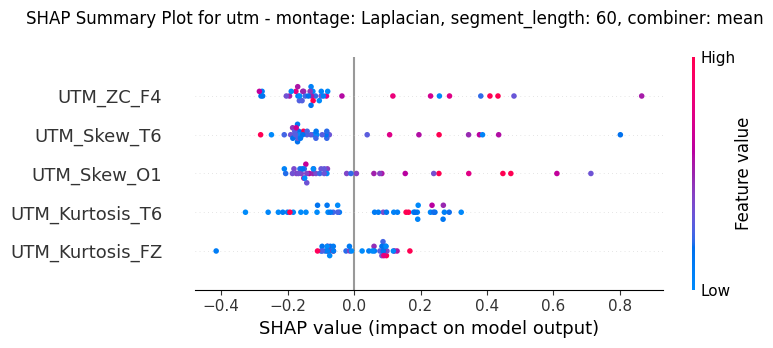

In [4]:
# For each selected feature, load data and compute LOSO SHAP values.
for feature_name in ['utm']:
    data, montage, segment_length, combiner = load_feature_data(feature_name)
    data = handle_complex_numbers(data)

    shap_values_folds = compute_shap_values_loso(data, labels, subjects, unique_subjects)

    create_shap_summary_plot(
        shap_values=shap_values_folds,
        data=data,
        feature_name=feature_name,
        montage=montage,
        segment_length=segment_length,
        combiner=combiner,
        max_display=5,
        custom_feature_names=feature_names,
        save_path=f'shap_summary_{feature_name}_tuh_withieds.pdf',
    )